In [ ]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys, time
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

### Simulated Hardware

In the [experimental holography](https://slmsuite.holodyne.com/en/latest/_examples/experimental_holography.html) tutorial, we claimed that
the uniformity of our spot arrays was limited by slow drift in the setup, and promised to
prove this using the `.simulate()` feature of `FourierSLM`. This feature ports a calibrated
experiment into simulation: the simulated SLM and camera inherit the measured geometry,
illumination, aberration, and phase response of the hardware. Projecting the same hologram
on both then shows exactly where the hardware deviates from its ideal.

In this example, we will:

- See what simulated hardware offers beyond the [computational holography](https://slmsuite.holodyne.com/en/latest/_examples/computational_holography.html) tutorial,
- Port our calibrated experiment to simulation,
- Compare spot power, spot shape, and uniformity between the two, and use the differences to diagnose and correct the hardware, and
- Use the simulation to vary what the hardware cannot: the SLM's bitdepth and phase response.

#### Why Simulate

Simulated hardware shares the `SLM` and `Camera` interfaces of physical hardware, so the
calibrations and algorithms in `slmsuite` run on it unchanged. It also offers a few things
that physical hardware cannot:

- **Ground truth.** The simulation knows its true aberration and phase response, so calibrations and algorithms can be scored against them.
- **Control.** Bitdepth, phase response, illumination, aberration, and camera noise are all parameters.
- **Stability and speed.** Simulated hardware does not drift, and a GPU renders a frame in milliseconds.

The computational holography tutorial used `SimulatedSLM` and `SimulatedCamera` only to
store device properties. A simulated camera can also *image*: once placed in the SLM's
$k$-space by a Fourier calibration (here, an analytic one for an ideal 100 mm lens), it
returns either
[.render()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameras.simulated.SimulatedCamera.html#slmsuite.hardware.cameras.simulated.SimulatedCamera.render),
the ideal farfield, or
[.get_image()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameras.camera.Camera.html#slmsuite.hardware.cameras.camera.Camera.get_image),
what a real sensor would deliver after exposure, noise, and quantization. Let's compare the
two on a log scale.

[INF] 17:29:27 SimulatedSLM Initialized SimulatedSLM.
[INF] 17:29:27 SimulatedCamera Initialized SimulatedCamera.
[INF] 17:29:27 Hologram Initialized Hologram.
[INF] 17:29:27 SimulatedCamera-SimulatedSLM Initialized FourierSLM.
[INF] 17:29:27 Hologram #2 Initialized Hologram.
[INF] 17:29:27 SimulatedCamera Autoexpose: 5.81e-03 s - 127/255


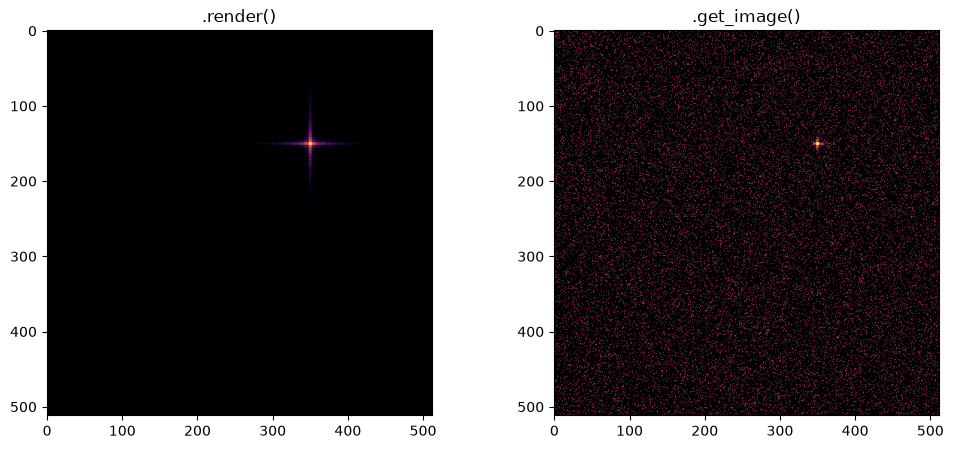

In [2]:
from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.hardware.cameras.simulated import SimulatedCamera, GaussianDetectorNoise
from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography import analysis, toolbox

slm = SimulatedSLM((512, 512), pitch_um=8, wav_um=0.532)
cam = SimulatedCamera(slm, (512, 512), pitch_um=4, noise=GaussianDetectorNoise(dark=.02, read=.003))
fs = FourierSLM(cam, slm)

M, b = fs.fourier_calibration_build(f_eff=100e3 / slm.wav_um)     # Ideal 100 mm lens.
fs.fourier_calibrate_analytic(M, b)

slm.set_phase(toolbox.phase.blaze(slm, fs.ijcam_to_kxyslm([[350], [150]])))  # Steer to pixel (350, 150).
cam.autoexpose(set_fraction=.5)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, img, title in zip(axs, (cam.render(), cam.get_image()), (".render()", ".get_image()")):
    ax.imshow(np.log10(np.clip(img / img.max(), 1e-4, None)))
    ax.set_title(title)
plt.show()

#### Loading Hardware

We load the same hardware and calibrations as in the
[experimental holography](https://slmsuite.holodyne.com/en/latest/_examples/experimental_holography.html) tutorial: a Texas Instruments
PLM (`'p67'`; 1358 $\times$ 800 pixels, 10.8 µm pitch, 4-bit) illuminated at 488 nm, and a
FLIR camera. One difference: an upstream SLM in our setup also blazes the beam, which can
push the Fourier calibration grid outside a cropped window of interest. So, we Fourier
calibrate on the full sensor, then crop the window around the zeroth order. The
calibration is stored in raw sensor pixels, so it survives the crop.

In [3]:
# ======================================== README ========================================
# ---------------- (This cell is hidden from readthedocs rendering) ---------------------
# If you're running this notebook without our hardware, run this cell instead of the
# next two. It loads a simulated clone of our setup (made with .simulate(), as below) to
# stand in for the hardware, so that the rest of the notebook runs. Of course, "hardware"
# and simulation will then agree much better than they do in our experiment.
fs = FourierSLM.load("simulated_setup.h5")
cam, slm = fs.cam, fs.slm
source_blaze = np.zeros((2, 1))

[INF] 17:29:28 p67_sim Initialized SimulatedSLM.
[INF] 17:29:28 flir_sim Initialized SimulatedCamera.
[INF] 17:29:28 Hologram #3 Initialized Hologram.
[INF] 17:29:28 flir_sim-p67_sim Initialized FourierSLM.
[WRN] 17:29:28 flir_sim Camera extends beyond the accessible SLM k-space; some pixels may not be targetable.
[INF] 17:29:28 Hologram #4 Initialized Hologram.


In [4]:
from slmsuite.hardware.slms.texasinstruments import PLM
from slmsuite.hardware.cameras.flir import FLIR

slm = PLM('p67', display_number=2, configure_usb=True, usb_device_number=1,
          wav_um=0.488, settle_time_s=0.05, name='PLM')
cam = FLIR(serial="22562470", pitch_um=2.74, bitdepth=12, name="FLIR Cam")
cam.set_woi(None)                   # Full sensor.

[INF] 17:29:29 PLM Initialized PLM on display 2.
[INF] 17:29:34 FLIR Cam Initialized FLIR.


(0, 5320, 0, 3032)

[INF] 17:29:34 FLIR Cam-PLM Initialized FourierSLM.
[INF] 17:29:34 FLIR Cam-PLM Loaded 'pixel' calibration from 'slm2_pixel_calibration_1-5V.h5'.
[INF] 17:29:34 FLIR Cam-PLM Loaded 'wavefront' calibration from 'slm2_superpixel_calibration_offset=0-25_wav=488.h5'.
[WRN] 17:29:34 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (4.2% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 31.48it/s]


[INF] 17:29:35 Fourier Grid Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 1275.64it/s]


[INF] 17:29:37 FLIR Cam Autoexpose: 2.66e-02 s - 1991/4095
[WRN] 17:29:39 holography.analysis 56.1% of the image's power outside the spot array. This might have caused the array fit to be poor.


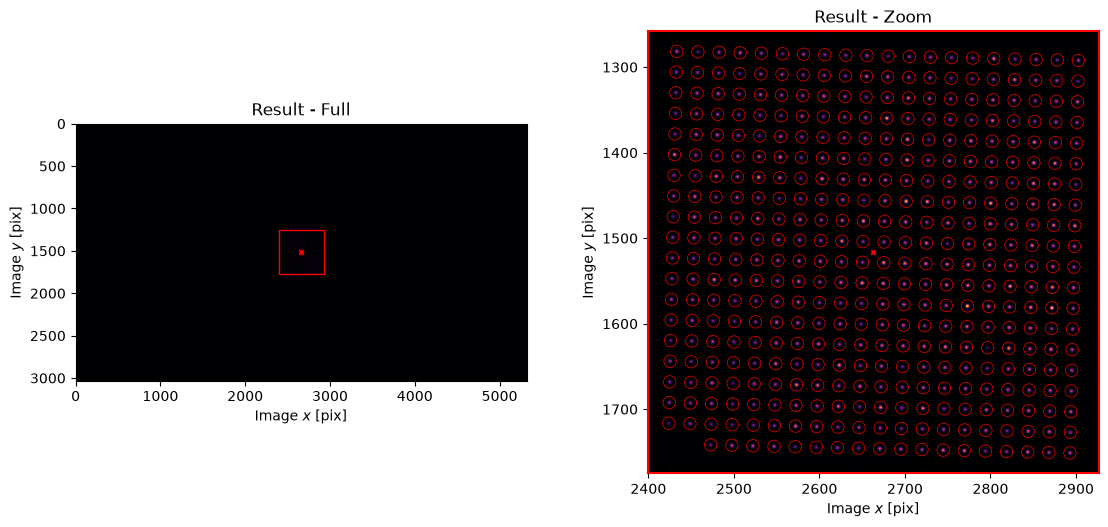

In [5]:
fs = FourierSLM(cam, slm)

fs.load_calibration('pixel', 'slm2_pixel_calibration_1-5V.h5')
fs.pixel_calibration_process(plot=False)
fs.load_calibration('wavefront', 'slm2_superpixel_calibration_offset=0-25_wav=488.h5')
fs.wavefront_calibration_superpixel_process(r2_threshold=.5, smooth=True, plot=False)

# Blaze the corrected light away from the undiffracted light.
source_blaze = np.array([[.28], [-.01]])                                    # [freq]
slm.source['phase'] += toolbox.phase.blaze(
    slm, toolbox.convert_vector(source_blaze, from_units="freq", to_units="norm", hardware=fs)
)

fs.fourier_calibrate(array_shape=20, array_pitch=20, autoexpose=True, plot=True);

In [6]:
x, y = fs.zeroth_order_ij.ravel()
cam.set_woi((int(x) - 512, 1024, int(y) - 512, 1024));

[WRN] 17:29:40 FLIR Cam Attempted to set WOI to (2151, 1024, 1004, 1024), but realized (2148, 1024, 1000, 1024).


#### Porting to Simulation

[.simulate()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameraslms.FourierSLM.html#slmsuite.hardware.cameraslms.FourierSLM.simulate)
clones the calibrated system into a new `FourierSLM` with simulated hardware. The clone
inherits:

- **Geometry**: the camera's position in the SLM's $k$-space (from the Fourier calibration), including the window of interest,
- **Illumination and aberration**: the source amplitude and phase measured by the wavefront calibration. The measured phase is a *correction*, so the simulated aberration is its negative, and applying the correction cancels it exactly,
- **Phase response**: the phase of each SLM level, measured by the pixel calibration, and
- **Camera settings**: pitch, bitdepth, and exposure.

Passing a hardware image as `reference` also sets the simulated camera's gain, so that
both cameras report the same counts for the same pattern. Note that `.simulate()` assumes
the Fourier calibration was taken with the current `slm.source["phase"]` applied, as we did
above (after adding the blaze).

We port the system while displaying the 19 $\times$ 19 spot array from the experimental
tutorial. We optimize it with *computational* feedback only, since camera feedback would
compensate for exactly the differences we want to see.

In [7]:
from slmsuite.holography.algorithms import SpotHologram

xlist = np.arange(50, 1000, 50)
square = np.vstack([grid.ravel() for grid in np.meshgrid(xlist, xlist)])

def solve(spot_amp=None):
    hologram = SpotHologram((2048, 2048), square, basis='ij', spot_amp=spot_amp, cameraslm=fs)
    hologram.optimize('WGS-Kim', maxiter=30, feedback='computational_spot')
    return hologram.get_phase()

phase = solve()
slm.set_phase(phase, settle=True)
cam.autoexpose(set_fraction=.5)

fs_sim = fs.simulate(reference=cam.get_image())

[INF] 17:29:40 SpotHologram Initialized SpotHologram.


100%|██████████| 30/30 [00:00<00:00, 136.98it/s]


[INF] 17:29:41 FLIR Cam Autoexpose: 3.47e-02 s - 2064/4095
[INF] 17:29:41 PLM_sim Initialized SimulatedSLM.
[INF] 17:29:41 FLIR Cam_sim Initialized SimulatedCamera.
[INF] 17:29:41 Hologram #5 Initialized Hologram.
[INF] 17:29:41 FLIR Cam_sim-PLM_sim Initialized FourierSLM.


#### Spot Power

The clone now displays the same array. Let's compare the two images, along with the power
in each spot, measured with [take()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.analysis.take.html) and
[image_normalization()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.analysis.image_normalization.html) as in
the experimental tutorial.

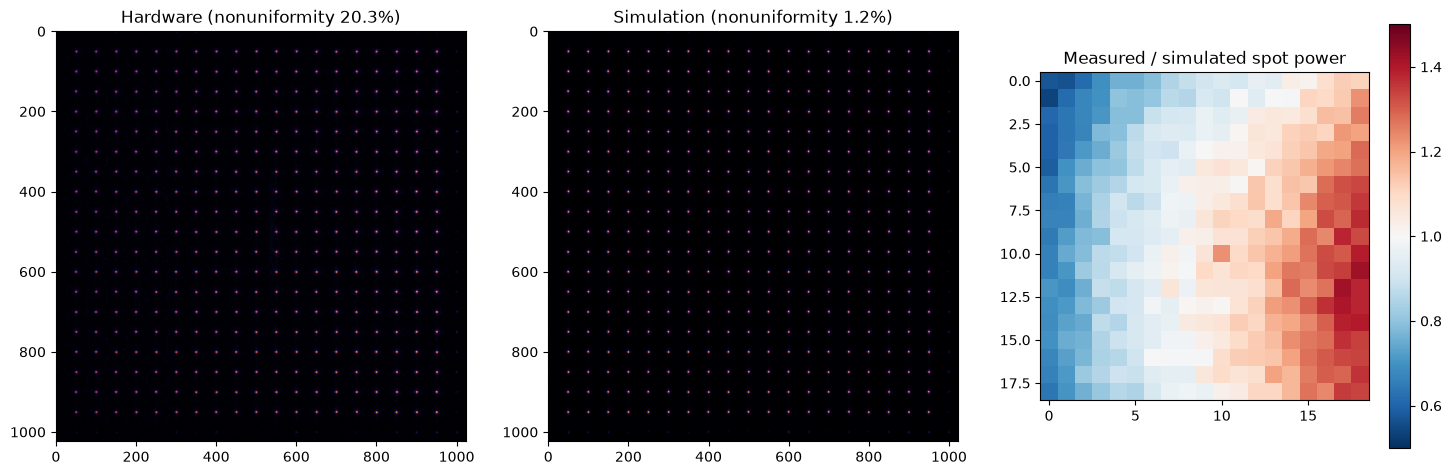

In [8]:
def spot_powers(img, vectors=square):
    return analysis.image_normalization(analysis.take(img - np.median(img), vectors, size=15))

img_hw, img_sim = cam.get_image(), fs_sim.cam.get_image()
p_hw, p_sim = spot_powers(img_hw), spot_powers(img_sim)
ratio = (p_hw / p_hw.mean()) / (p_sim / p_sim.mean())

fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))
vmax = np.sqrt(max(img_hw.max(), img_sim.max()))
for ax, img, p, title in zip(axs, (img_hw, img_sim), (p_hw, p_sim), ("Hardware", "Simulation")):
    ax.imshow(np.sqrt(np.clip(img - np.median(img), 0, None)), vmin=0, vmax=vmax)
    ax.set_title("{} (nonuniformity {:.1%})".format(title, p.std() / p.mean()))
im = axs[2].imshow(ratio.reshape(len(xlist), -1), cmap="RdBu_r", vmin=.5, vmax=1.5)
axs[2].set_title("Measured / simulated spot power")
plt.colorbar(im, ax=axs[2])
plt.show()

The simulation is nearly uniform, but the hardware is not: the measured spot powers
fall off smoothly toward the left of the field. We noticed this in the experimental
tutorial too. The direction is the clue. The undiffracted light lies just past the right
edge of the window (displaced by the blaze we added to the source), and spots get dimmer
the farther they are steered from it.

The simulation models each SLM pixel as a point, but each real pixel is a mirror with
finite width. The farfield is therefore weighted by the diffraction pattern of a single
pixel, $\mathrm{sinc}^2(f_x)\,\mathrm{sinc}^2(f_y)$, centered on the undiffracted light.
Here, $\vec{f}$ is the spatial frequency displayed on the SLM in cycles per pixel (the
`"freq"` unit in `slmsuite`), so for a fill factor of 100% the envelope is zero at the
pixel-pitch diffraction orders, $\vec{f} = \pm 1$. For each spot, $\vec{f}$ is its position
converted to `"freq"` with
[convert_vector()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.toolbox.convert_vector.html), plus the source
blaze. This gives a prediction with no free parameters:

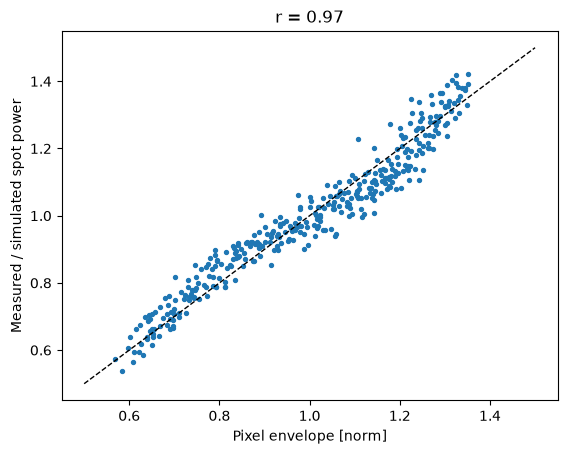

In [9]:
freq = toolbox.convert_vector(square, from_units="ij", to_units="freq", hardware=fs) + source_blaze
envelope = np.sinc(freq[0]) ** 2 * np.sinc(freq[1]) ** 2

plt.scatter(envelope / envelope.mean(), ratio, s=8)
plt.plot([.5, 1.5], [.5, 1.5], "k--", lw=1)
plt.xlabel("Pixel envelope [norm]")
plt.ylabel("Measured / simulated spot power")
plt.title("r = {:.2f}".format(np.corrcoef(envelope, ratio)[0, 1]))
plt.show()

The prediction matches the measurement. To compensate, we ask WGS for spot amplitudes
proportional to $1/\sqrt{\text{envelope}}$, so that the envelope evens out the spot powers:

In [10]:
phase_compensated = solve(spot_amp=1 / np.sqrt(envelope))
slm.set_phase(phase_compensated, settle=True)
p_compensated = spot_powers(cam.get_image())

print("Hardware nonuniformity: {:.1%} -> {:.1%}".format(
    p_hw.std() / p_hw.mean(), p_compensated.std() / p_compensated.mean()))

[INF] 17:29:42 SpotHologram #2 Initialized SpotHologram.


100%|██████████| 30/30 [00:00<00:00, 583.75it/s]

Hardware nonuniformity: 20.3% -> 5.2%

Much more uniform, still without any camera feedback.

#### Spot Shape

Next, the shape of each spot. The clone's aberration is exactly the measured correction, so
its corrected spots are diffraction-limited. This makes the clone an ideal reference for the
[Strehl ratio](https://en.wikipedia.org/wiki/Strehl_ratio) $S$ of each hardware spot (its
peak intensity relative to that of a diffraction-limited spot with the same power).
[image_strehl()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.analysis.image_strehl.html) compares each
hardware spot to the clone's spot at the same position, which also accounts for how each
spot falls on the camera's pixels.

We also turn the wavefront correction off on both, keeping only the source blaze so that
the spots stay in place. The clone knows the aberration only through the wavefront
calibration, so if the calibration is accurate, both should degrade in the same way.

Hardware, corrected: Strehl ratio 0.80 +/- 0.04
Simulation, corrected: Strehl ratio 1.00 +/- 0.00
Hardware, uncorrected: Strehl ratio 0.13 +/- 0.01
Simulation, uncorrected: Strehl ratio 0.12 +/- 0.01


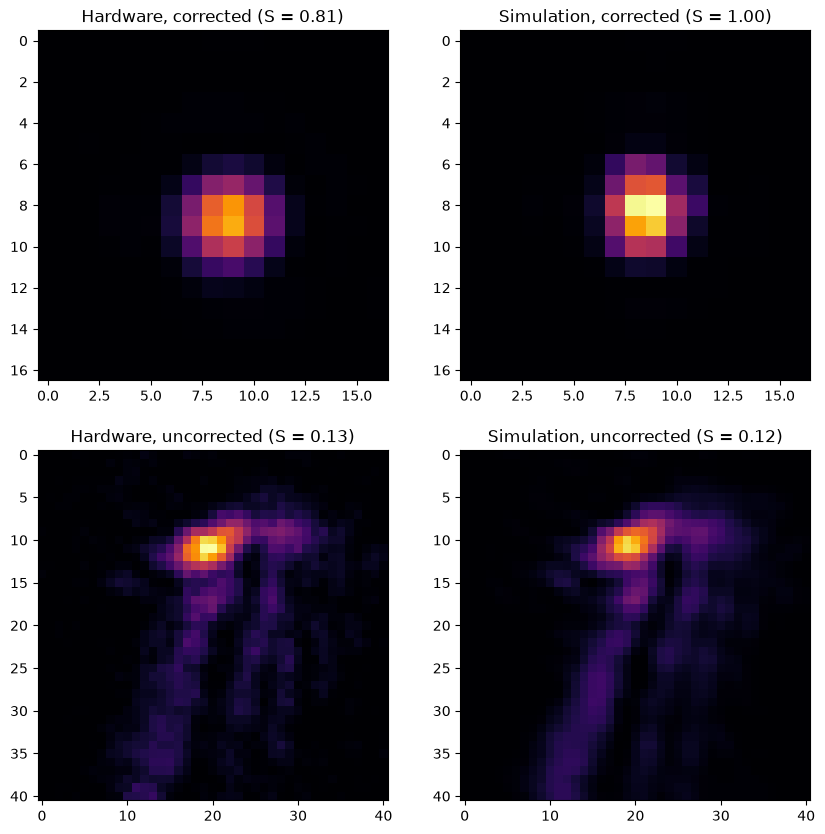

In [11]:
from slmsuite.misc.xp import as_numpy

blaze = as_numpy(toolbox.phase.blaze(
    slm, toolbox.convert_vector(source_blaze, from_units="freq", to_units="norm", hardware=fs)
))

def spots(fs_, phase_correct):
    # Displays the array, with or without the wavefront correction, and crops each spot.
    fs_.slm.set_phase(phase if phase_correct else phase + blaze, phase_correct=phase_correct, settle=True)
    img = fs_.cam.get_image()
    return analysis.take(img - np.median(img), square, size=41)

reference = spots(fs_sim, True)                         # Diffraction-limited.
measured = {
    "corrected": {"Hardware": spots(fs, True), "Simulation": reference},
    "uncorrected": {"Hardware": spots(fs, False), "Simulation": spots(fs_sim, False)},
}

i = len(xlist) ** 2 // 2                                # The center spot.
zoom = {"corrected": slice(12, 29), "uncorrected": slice(None)}  # The corrected spots are small.
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for row, (state, spots_) in zip(axs, measured.items()):
    vmax = max(s[i].max() / s[i].sum() for s in spots_.values())
    for ax, (source, s) in zip(row, spots_.items()):
        strehl = analysis.image_strehl(s, reference)
        print("{}, {}: Strehl ratio {:.2f} +/- {:.2f}".format(source, state, strehl.mean(), strehl.std()))
        spot = s[i] / s[i].sum()                            # Equal power, so peak height shows S.
        ax.imshow(spot[zoom[state], zoom[state]], vmin=0, vmax=vmax)
        ax.set_title("{}, {} (S = {:.2f})".format(source, state, strehl[i]))
plt.show()

With the correction off, the clone reproduces the aberrated hardware spots in both shape and
Strehl ratio, so the wavefront calibration measured the aberration well. With the
correction on, the hardware's spots are broader than the clone's, with a lower peak:
a Strehl ratio $S$ of about 0.8 in our runs (printed above), consistently across the array.
Using the Maréchal approximation $S \approx e^{-\sigma^2}$, this corresponds to a residual
wavefront error of $\sigma = \sqrt{-\ln S} \approx 0.45$ radians rms (about $\lambda/14$) that the
calibration did not capture. Since the residual is uniform across the field, it is not the
field-dependent aberration addressed in the
[multipoint calibration](https://slmsuite.holodyne.com/en/latest/_examples/multipoint_calibration.html) tutorial.

#### Varying What the Hardware Cannot

Our PLM displays 16 phase levels (4 bits). Would an SLM with more levels do better? We
cannot swap the SLM in our experiment, but we can swap the one in the clone. Below, we
build a simulated SLM for each bitdepth, with evenly spaced levels and the clone's
illumination, and a simulated camera at the same position as the clone's. We then display
the same hologram on each and measure the total power in the array with the noiseless
`.render()`.

Rounding a phase pattern to $N$ evenly spaced levels keeps a fraction
$\mathrm{sinc}^2(1/N)$ of the light in the intended pattern; the rest is diffracted into
other orders, which here (thanks to the source blaze) fall outside the window. We normalize to 8 bits, where this fraction
is essentially 1.

[INF] 17:29:42 SimulatedSLM #2 Initialized SimulatedSLM.
[INF] 17:29:42 SimulatedCamera #2 Initialized SimulatedCamera.
[INF] 17:29:43 Hologram #6 Initialized Hologram.
[INF] 17:29:43 SimulatedCamera-SimulatedSLM #2 Initialized FourierSLM.
[INF] 17:29:43 SimulatedSLM #3 Initialized SimulatedSLM.
[INF] 17:29:43 SimulatedCamera #3 Initialized SimulatedCamera.
[INF] 17:29:43 Hologram #7 Initialized Hologram.
[INF] 17:29:43 SimulatedCamera-SimulatedSLM #3 Initialized FourierSLM.
[INF] 17:29:43 SimulatedSLM #4 Initialized SimulatedSLM.
[INF] 17:29:43 SimulatedCamera #4 Initialized SimulatedCamera.
[INF] 17:29:43 Hologram #8 Initialized Hologram.
[INF] 17:29:43 SimulatedCamera-SimulatedSLM #4 Initialized FourierSLM.
[INF] 17:29:43 SimulatedSLM #5 Initialized SimulatedSLM.
[INF] 17:29:43 SimulatedCamera #5 Initialized SimulatedCamera.
[INF] 17:29:43 Hologram #9 Initialized Hologram.
[INF] 17:29:43 SimulatedCamera-SimulatedSLM #5 Initialized FourierSLM.
[INF] 17:29:43 SimulatedSLM #6 Initializ

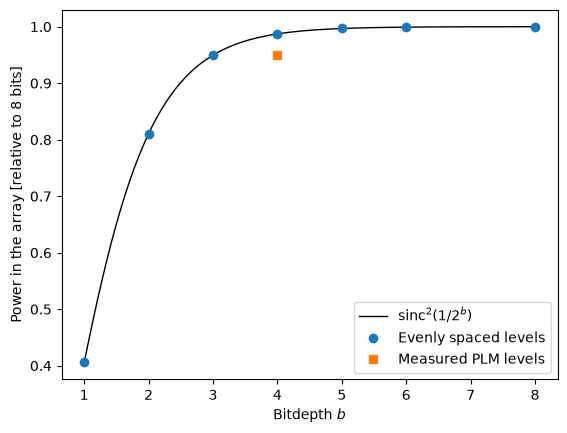

Measured PLM levels: 0.951; evenly spaced 3 bits: 0.950, 4 bits: 0.987


In [12]:
def clone_with_bitdepth(bitdepth):
    # The clone's illumination and camera position, with an SLM of evenly spaced levels.
    slm_b = SimulatedSLM(np.flip(slm.shape), pitch_um=slm.pitch_um, wav_um=slm.wav_um,
                         bitdepth=bitdepth, source=fs_sim.slm.source)
    cam_b = SimulatedCamera(slm_b, np.flip(cam.shape), M=fs_sim.cam.M, b=fs_sim.cam.b)
    return FourierSLM(cam_b, slm_b)

def array_power(fs_):
    fs_.slm.set_phase(phase)
    return spot_powers(fs_.cam.render()).sum()

bitdepths = [1, 2, 3, 4, 5, 6, 8]
power = np.array([array_power(clone_with_bitdepth(bitdepth)) for bitdepth in bitdepths])
efficiency = power / power[-1]
efficiency_plm = array_power(fs_sim) / power[-1]        # The clone has the PLM's measured levels.

bits = np.linspace(1, 8, 100)
plt.plot(bits, np.sinc(1 / 2 ** bits) ** 2, "k-", lw=1, label="$\\mathrm{sinc}^2(1/2^b)$")
plt.plot(bitdepths, efficiency, "o", label="Evenly spaced levels")
plt.plot(4, efficiency_plm, "s", label="Measured PLM levels")
plt.xlabel("Bitdepth $b$")
plt.ylabel("Power in the array [relative to 8 bits]")
plt.legend()
plt.show()

print("Measured PLM levels: {:.3f}; evenly spaced 3 bits: {:.3f}, 4 bits: {:.3f}".format(
    efficiency_plm, efficiency[2], efficiency[3]))

The simulation follows the theory, and shows that little is gained beyond 4 bits. However,
the PLM's 16 measured levels perform about as well as 8 evenly spaced levels (compare the
printed values): their uneven spacing costs roughly a full bit, even with the pixel
calibration applied.

#### Gamma Correction

That pixel calibration (also called the gamma or LUT calibration) measured the phase that
each of the 16 levels actually produces. The clone stores this response in two places:

- `slm.gamma` is the response the SLM *assumes* when choosing a level for each phase (set by [set_gamma()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.slms.slm.SLM.html#slmsuite.hardware.slms.slm.SLM.set_gamma)), and
- `slm.gamma_sim` is the response the simulated SLM *actually* has.

`.simulate()` sets both to the measured response. On the hardware, only `slm.gamma` exists:
the actual response is whatever the PLM does. Let's plot the measured response against
evenly spaced levels, which is what an SLM without a pixel calibration would assume.

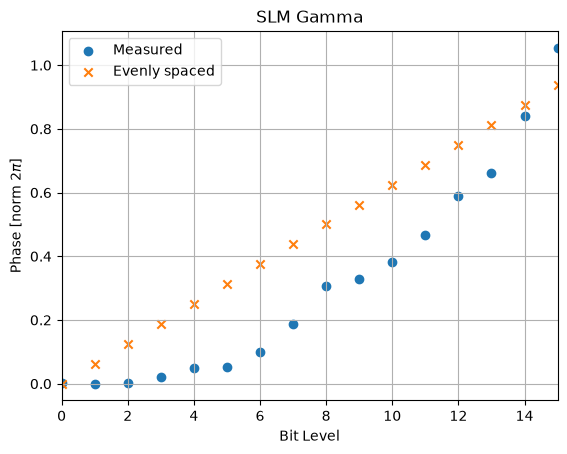

In [13]:
gamma = as_numpy(slm.gamma)                                     # The measured response.
linear = np.arange(slm.bitresolution) / slm.bitresolution       # Evenly spaced levels.

fig, ax = plt.subplots()
slm.plot_gamma(ax=ax, label="Measured")
slm.plot_gamma(linear, ax=ax, marker="x", label="Evenly spaced")
ax.legend(loc="upper left")
plt.show()

Now, let's remove the gamma correction (assume evenly spaced levels) on both the hardware
and the clone. Light that leaves the array goes into other diffraction orders, mostly
outside our window, so we first widen the window and clone the system again: a clone's
camera is built from the window at the moment of cloning.

For a third prediction, we also remove the measured response from the clone itself
(`gamma_sim = None`). This is the simulation we would have written without measuring the
response: since it assumes evenly spaced levels, the correction makes no difference to it.

[WRN] 17:29:43 FLIR Cam Attempted to set WOI to (1399, 2528, 492, 2048), but realized (1396, 2528, 488, 2048).
[INF] 17:29:43 PLM_sim #2 Initialized SimulatedSLM.
[INF] 17:29:43 FLIR Cam_sim #2 Initialized SimulatedCamera.
[WRN] 17:29:43 FLIR Cam_sim #2 Camera extends beyond the accessible SLM k-space; some pixels may not be targetable.
[INF] 17:29:43 Hologram #13 Initialized Hologram.
[INF] 17:29:43 FLIR Cam_sim-PLM_sim #2 Initialized FourierSLM.
[WRN] 17:29:44 FLIR Cam Attempted to set WOI to (2151, 1024, 1004, 1024), but realized (2148, 1024, 1000, 1024).


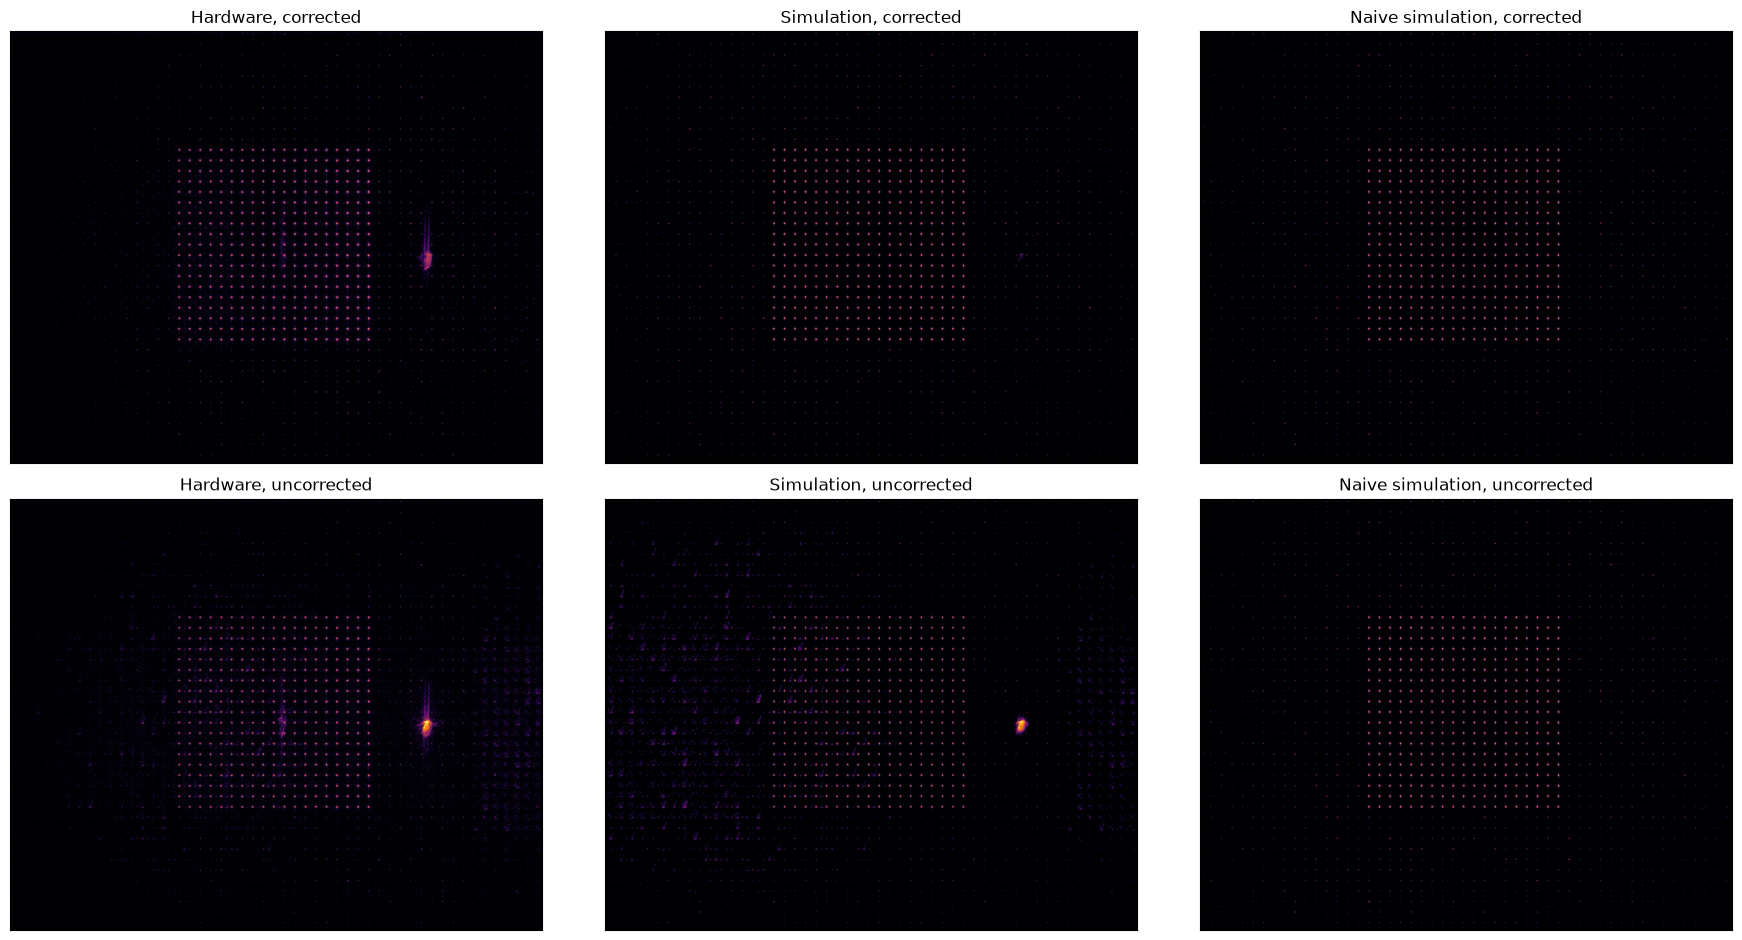

        Hardware: 0.67 of the array's power remains without the gamma correction
      Simulation: 0.67 of the array's power remains without the gamma correction
Naive simulation: 1.00 of the array's power remains without the gamma correction


In [14]:
cam.set_woi((int(x) - 1264, 2528, int(y) - 1024, 2048))     # Wide enough to see the other orders.
slm.set_phase(phase, settle=True)
fs_wide = fs.simulate(reference=cam.get_image())
square_wide = fs.kxyslm_to_ijcam(fs_sim.ijcam_to_kxyslm(square))  # The array, in the wide window.

def image(fs_):
    fs_.slm.set_phase(phase, settle=True)
    return fs_.cam.get_image()

corrected = {"Hardware": image(fs), "Simulation": image(fs_wide)}

slm.set_gamma(linear)
fs_wide.slm.set_gamma(linear)
uncorrected = {"Hardware": image(fs), "Simulation": image(fs_wide)}

fs_wide.slm.gamma_sim = None
corrected["Naive simulation"] = uncorrected["Naive simulation"] = image(fs_wide)

slm.set_gamma(gamma)                                            # Restore the hardware.
cam.set_woi((int(x) - 512, 1024, int(y) - 512, 1024))

fig, axs = plt.subplots(2, 3, figsize=(18, 9.5))
for row, (state, images) in zip(axs, (("corrected", corrected), ("uncorrected", uncorrected))):
    for ax, (label, img) in zip(row, images.items()):
        ax.imshow(np.log10(np.clip(img - np.median(img), 1, None)), vmin=0, vmax=np.log10(cam.bitresolution))
        ax.set_title("{}, {}".format(label, state))
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()

for label in uncorrected:
    kept = spot_powers(uncorrected[label], square_wide).sum() / spot_powers(corrected[label], square_wide).sum()
    print("{:>16s}: {:.2f} of the array's power remains without the gamma correction".format(label, kept))

Without the gamma correction, the array keeps only about two thirds of its power (printed
above), on both the hardware and the clone. The images show where the rest goes: into the undiffracted light
(right of the array) and a faint lattice of ghost spots across the field, which are other
diffraction orders of the hologram. The clone reproduces both, while the naive simulation
predicts that nothing changes. Had we not yet measured the response, this disagreement
between experiment and simulation would have told us both that something was wrong and
what the simulation was missing.

Notice also that the hardware's undiffracted light is bright even *with* the correction,
while the clone's is not. This light is not explained by the phase response, which makes it
a candidate for the next round of comparison.

#### What Limits Uniformity

Finally, we return to the question from the experimental tutorial. There, camera feedback
(`'experimental_spot'`) made the array much more uniform, but not perfectly so. Let's run
the same feedback on the hardware and on the clone, and compare the statistics as they
converge. Here we skip the computational preconditioning, so the statistics cover every
iteration; feedback simply takes a few more iterations to converge.

[INF] 17:29:46 SpotHologram #3 Initialized SpotHologram.


100%|██████████| 40/40 [00:10<00:00,  3.85it/s]

[INF] 17:29:57 SpotHologram #4 Initialized SpotHologram.



100%|██████████| 40/40 [00:00<00:00, 105.48it/s]


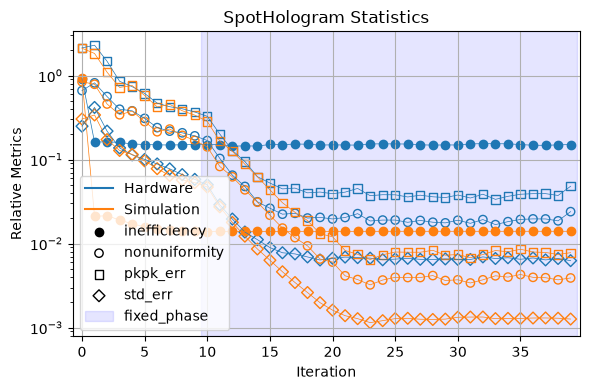

In [15]:
def optimize_with_feedback(fs_):
    hologram = SpotHologram((2048, 2048), square, basis='ij', cameraslm=fs_)
    hologram.spot_integration_width_ij = 15
    hologram.optimize('WGS-Kim', maxiter=40, feedback='experimental_spot', stat_groups=['experimental_spot'])
    return hologram

hologram_hw = optimize_with_feedback(fs)
hologram_sim = optimize_with_feedback(fs_sim)

stats = hologram_hw.stats
stats["stats"]["Hardware"] = stats["stats"].pop("experimental_spot")
stats["stats"]["Simulation"] = hologram_sim.stats["stats"]["experimental_spot"]
hologram_hw.plot_stats(stats);

The simulation converges to a very low nonuniformity (`std_err`), the limit set by the
algorithm and the PLM's 16 levels. The hardware stalls well above it. Camera noise
is one candidate. Drift is the other: if the spots change between the frames used for
feedback, the feedback chases a moving target.

To tell them apart, we stop the feedback, leave both patterns on their SLMs, and measure
the nonuniformity every few seconds for 30 seconds. Each measurement sums 8 frames, to
suppress camera noise.

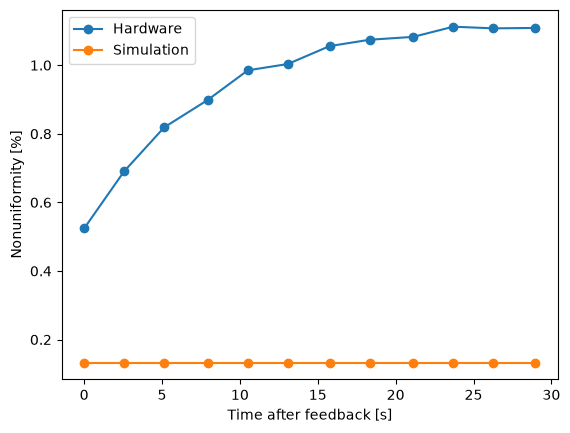

In [16]:
slm.set_phase(hologram_hw.get_phase(), settle=True)
fs_sim.slm.set_phase(hologram_sim.get_phase())

times, nonuniformity = [], {"Hardware": [], "Simulation": []}
start = time.time()
while time.time() - start < 30:
    times.append(time.time() - start)
    for label, fs_ in (("Hardware", fs), ("Simulation", fs_sim)):
        p = spot_powers(fs_.cam.get_image(averaging=8))
        nonuniformity[label].append(100 * p.std() / p.mean())
    time.sleep(2)

for label, values in nonuniformity.items():
    plt.plot(times, values, "o-", label=label)
plt.xlabel("Time after feedback [s]")
plt.ylabel("Nonuniformity [%]")
plt.legend()
plt.show()

The simulation does not change, as expected. The hardware starts near the level where its
feedback stalled, then grows within seconds, even though the SLM pattern is
fixed and the camera noise is averaged down: the spot powers themselves are drifting. This
is the limit we saw in the experimental tutorial, and no algorithm can remove it, since
feedback can only correct the array as it was when the camera captured it. Reducing it
means stabilizing the setup (laser power and pointing, temperature) or keeping the feedback
running.

In each section, the simulated clone separated what our hardware *could* do from what it
*does*, and the difference pointed to the physics responsible: the pixel envelope, residual
aberration, the phase response, and drift. We look forward to seeing what you find in your
own setups!

In [17]:
cam.close()
slm.close()